# Stock Price Prediction Models

#### Ongoing Tasks to complete:

- Add full introduction when project is complete
- Research walk-forward validation
- Look into block bootstrap
- Discuss survivorship bias in conclusion

#### Immediate next steps:

- Reorganise section on ACF, PACF plots.
- Add tqdm to conda environment.

## Contents

1. [Introduction](#introduction)
2. [Setup](#setup)
3. [Data Collection](#data-collection)
4. [Data Cleaning](#data-cleaning)
5. [Data Analysis](#data-analysis)
6. [Model Fitting](#model-fitting)
7. [Model Evaluation](#model-evaluation)
8. [Conclusion](#conclusion)

## Introduction

Predicting stock prices is a notoriously challenging problem but one of great interest. Many have attempted to do so with mixed results. The primary reason for the difficulty lies in the efficient market hypothesis; the idea that any given stock's price reflects its true value and no discrepancies exist. If this is true, it would suggest there is no information that can be gleaned from historical data. There are many arguments to be made for and against this but regardless of its validity, it is clear that markets are very efficient, even if not fully, and this makes predicting stocks challenging as there is typically a very low signal to noise ratio in historical stock data. Other issues that make this can include the limitations of the dataset used; certain datasets may reflect patterns that were only present at a given moment in history.

**Project Aim:** The purpose of this project is predict stock prices given past historical data. We will measure whether the prediction correctly predicts the direction in which a stock will move. Knowing this with any chance greater than 50% will ultimately provide an advantage, although the magnitude of such an advantage will depend on several variables which we will discuss later. We will compare several predictive models and assess our level of confidence in these predictions by conducting a hypothesis test using walk-forward validation.

## Setup

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import yfinance as yf
import requests
from io import StringIO
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from tqdm import tqdm

## Data Collection

The first task is choosing which stocks to analyse. We will use several criteria:
- Sufficient historic data
- Sufficiently liquid stocks
- Moderately volatile stocks
- Weakly correlated and from different sectors

For the first criteria, we'll only consider stocks that have data from 1990 to present day. This time period covers several key financial events: the dotcom bubble (2000), the financial crash (2008), the COVID-19 pandemic (2020) and others and will help test how well are predictions cope under rare and drastic events. We want to examine stocks with high liquidity as these stocks typically have cleaner price data. Moderate volatility makes the prediction interesting, stocks with little volatility are easier to predict but high volatility stocks likely have a worse signal to noise ratio. We'll also examine stocks from different sectors, this should help to ensure they are weakly correlated.

To help narrow down our search, we'll examine stocks from the S&P500. Such stocks have a long history and are highly liquid, thus fulfilling the first two criteria. We'll scrape the data from Wikipedia and filter companies by annualised volatility.

In [2]:
# Scrape Wikipedia page for S&P 500 table

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
html = requests.get(url, headers={'User-Agent':'Mozilla/5.0'}).text
df = pd.read_html(StringIO(html))[0]

# Download S&P 500 stocks from 1990 to 2026

# tickers = list(df['Symbol'])
# sp500_stocks = yf.download(tickers, start='1990-01-01', end='2026-01-01')

# Or retrieve locally to save re-downloading

sp500_stocks = pd.read_csv('sp500_stocks.csv', index_col=0, parse_dates=True, header=[0,1])

In [3]:
# Save large stock download locally to save time between sessions

# sp500_stocks.to_csv('./sp500_stocks.csv')

In [4]:
# Filter by close price and drop any stocks which don't have complete data from 1990
# Only 235 stocks remain after this

close_prices = sp500_stocks.loc[:,'Close'].dropna(axis=1)

# Now compute annualised volatility

annualised_volatility = close_prices.pct_change().std()*np.sqrt(252)

# Filter by stocks with a volatility between 20 and 35%
# This gives us 151 stocks

moderate_volatility_stocks = close_prices.loc[:, (annualised_volatility<=0.35) & (annualised_volatility>=0.2)]

# Check what sectors are most frequently appearing

sectors = df[df['Symbol'].isin(moderate_volatility_stocks)].groupby('GICS Sector').count().sort_values(by='Symbol', ascending=False)
sectors.head()

,Symbol,Security,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
GICS Sector,,,,,,,
Industrials,32,32,32,32,32,32,32
Consumer Staples,17,17,17,17,17,17,17
Financials,16,16,16,16,16,16,16
Health Care,16,16,16,16,16,16,16
Utilities,16,16,16,16,16,16,16


Industrials, consumer staples and and financials are the biggest sectors shortly followed by utilities. These sectors all behave in fundamentally different ways during regime changes, making them fairly excellent candidates for our analysis. Utilities is a close 4th, but is quite similar to consumer staples in that it typically performs well during economic downturn due to its inherent necessity. In order to avoid any familiarity bias, we'll select the first stock from each sector. It is worth noting that due to Yahoo Finance's frequent updates and delisting of certain stocks, this process can suffer from reproducibility. When this was first conducted, the selected stocks were: COST, SPGI, PNR. We will use these going forward.

In [5]:
stocks = df[df['GICS Sector'].isin(sectors.index[0:3] ) & df['Symbol'].isin(moderate_volatility_stocks)].sort_values(by='GICS Sector').drop_duplicates('GICS Sector')
stocks

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
131,COST,Costco,Consumer Staples,Consumer Staples Merchandise Retail,"Issaquah, Washington",1993-10-01,909832,1976
402,SPGI,S&P Global,Financials,Financial Exchanges & Data,"New York City, New York",1957-03-04,64040,1917
361,PAYX,Paychex,Industrials,Human Resource & Employment Services,"Penfield, New York",1998-10-01,723531,1971


We compute the correlation on returns between these stocks, looking for a correlation of 0.4 or less, and see that these stocks match the criteria. We now have our chosen stocks to analyse.

In [6]:
# Isolate selected stocks. Necessary to account for reproducibility issue noted above.

idx = pd.IndexSlice
stocks = sp500_stocks.loc[:,idx[:,['COST','SPGI','PNR']]]

# Check correlation on returns

returns = stocks['Close'].pct_change()
returns.corr()

Ticker,COST,SPGI,PNR
Ticker,,,
COST,1.000000,0.305766,0.253909
SPGI,0.305766,1.000000,0.382453
PNR,0.253909,0.382453,1.000000


## Data Cleaning

We perform some quick checks for missing values and duplicates on the data before proceeding.

In [7]:
# Check for nulls
stocks.isnull().sum().sum()

np.int64(0)

In [8]:
# Check for duplicates
stocks.duplicated().sum()

np.int64(0)

In [9]:
# Check date range
stocks.index.min(), stocks.index.max()

(Timestamp('1990-01-02 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [10]:
# Check data shape
stocks.shape

(9067, 15)

The dataset appears clean, and we may proceed.

## Data Analysis

We'll begin the data analysis by inspecting the plots of closing prices and returns for each of the three stocks.

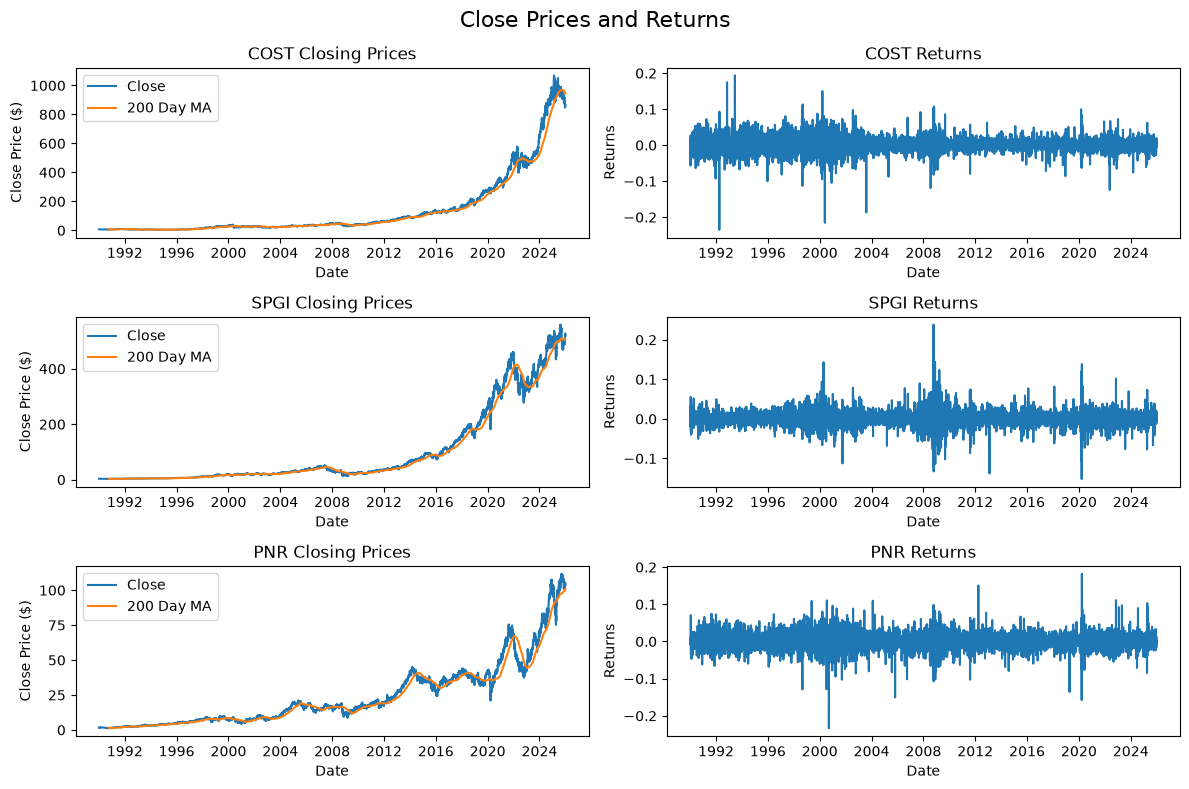

In [11]:
fig, ax = plt.subplots(3,2, figsize=(12,8))

ax[0,0].plot(stocks.loc[:,('Close','COST')])
ax[0,0].plot(stocks.loc[:,('Close','COST')].rolling(window=200).mean(), color='tab:orange')
ax[0,0].set_title('COST Closing Prices')
ax[0,0].set_xlabel('Date')
ax[0,0].set_ylabel('Close Price ($)')
ax[0,0].legend(['Close', '200 Day MA'])

ax[0,1].plot(returns['COST'])
ax[0,1].set_title('COST Returns')
ax[0,1].set_xlabel('Date')
ax[0,1].set_ylabel('Returns')

ax[1,0].plot(stocks.loc[:,('Close','SPGI')])
ax[1,0].plot(stocks.loc[:,('Close','SPGI')].rolling(window=200).mean(), color='tab:orange')
ax[1,0].set_title('SPGI Closing Prices')
ax[1,0].set_xlabel('Date')
ax[1,0].set_ylabel('Close Price ($)')
ax[1,0].legend(['Close', '200 Day MA'])

ax[1,1].plot(returns['SPGI'])
ax[1,1].set_title('SPGI Returns')
ax[1,1].set_xlabel('Date')
ax[1,1].set_ylabel('Returns')

ax[2,0].plot(stocks.loc[:,('Close','PNR')])
ax[2,0].plot(stocks.loc[:,('Close','PNR')].rolling(window=200).mean(), color='tab:orange')
ax[2,0].set_title('PNR Closing Prices')
ax[2,0].set_xlabel('Date')
ax[2,0].set_ylabel('Close Price ($)')
ax[2,0].legend(['Close', '200 Day MA'])

ax[2,1].plot(returns['PNR'])
ax[2,1].set_title('PNR Returns')
ax[2,1].set_xlabel('Date')
ax[2,1].set_ylabel('Returns')

fig.suptitle('Close Prices and Returns', fontsize=16)

plt.tight_layout()

The close prices of the stocks clearly exhibit non-stationarity as expected. We confirm this rigorously later on. We also see evidence of volatility clustering in the returns plots. We take a look at the 200 day rolling volatility of each of the stocks below.

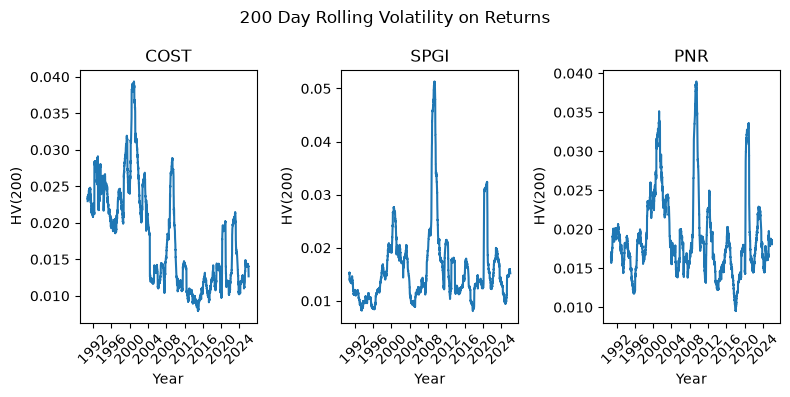

In [12]:
fig, ax = plt.subplots(1,3, figsize=(8,4))

ax[0].plot(returns['COST'].rolling(window=200).std())
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_xlabel('Year')
ax[0].set_ylabel('HV(200)')
ax[0].set_title('COST')

ax[1].plot(returns['SPGI'].rolling(window=200).std())
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_xlabel('Year')
ax[1].set_ylabel('HV(200)')
ax[1].set_title('SPGI')

ax[2].plot(returns['PNR'].rolling(window=200).std())
ax[2].tick_params(axis='x', rotation=45)
ax[2].set_xlabel('Year')
ax[2].set_ylabel('HV(200)')
ax[2].set_title('PNR')

fig.suptitle('200 Day Rolling Volatility on Returns')
plt.tight_layout()

As before, we observe noticable volatility clustering. This primarily occurs approximately around the years 2001, 2009, 2020 which likely coincides with 9/11, the '08 financial crash and the COVID-19 crisis.

We will also examine the histograms of the returns.

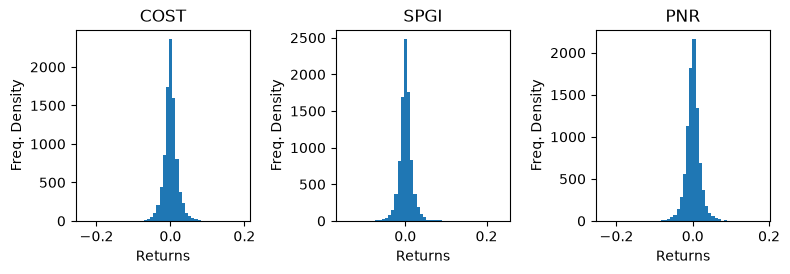

In [13]:
fig, ax = plt.subplots(1,3, figsize=(8,3))

ax[0].hist(returns['COST'], bins=50)
ax[0].set_title('COST')
ax[0].set_xlabel('Returns')
ax[0].set_ylabel('Freq. Density')
ax[1].hist(returns['SPGI'], bins=50)
ax[1].set_title('SPGI')
ax[1].set_xlabel('Returns')
ax[1].set_ylabel('Freq. Density')
ax[2].hist(returns['PNR'], bins=50)
ax[2].set_title('PNR')
ax[2].set_xlabel('Returns')
ax[2].set_ylabel('Freq. Density')

fig.suptitle('')

plt.tight_layout()

The returns  clearly have a large degree of kurtosis, a known property of stock returns. We verify this with a Jarque-Bera test on each of the returns.

In [14]:
stat, p_value = stats.jarque_bera(returns['COST'].dropna())
print(f'P-value for COST returns: {p_value : .3}')
stat, p_value = stats.jarque_bera(returns['SPGI'].dropna())
print(f'P-value for SPGI returns: {p_value : .3}')
stat, p_value = stats.jarque_bera(returns['PNR'].dropna())
print(f'P-value for PNR returns: {p_value : .3}')

P-value for COST returns:  0.0
P-value for SPGI returns:  0.0
P-value for PNR returns:  0.0


As expected, all three stocks return statistically significant results suggesting they are not, in fact, normally distributed. We turn our attention now to the ACF plots for each of the stocks for both close prices and returns.

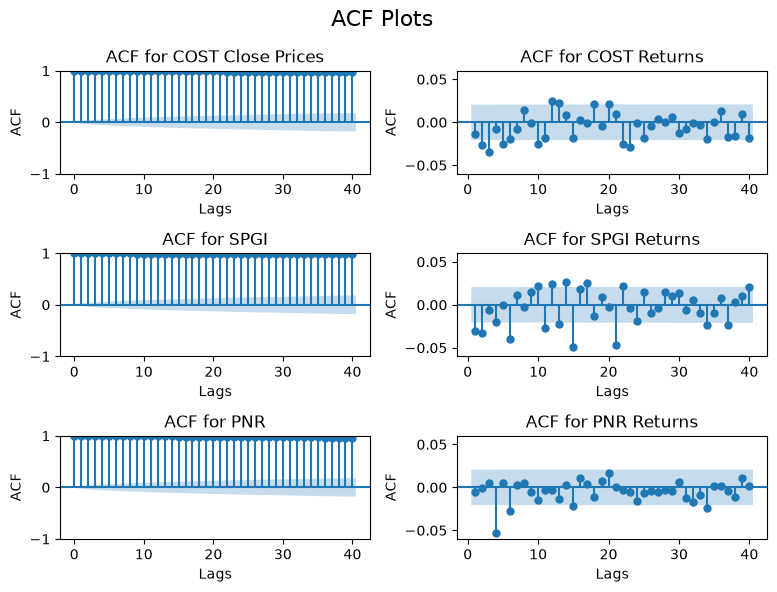

In [15]:
fig, ax = plt.subplots(3,2, figsize=(8,6))

plot_acf(stocks.loc[:,('Close','COST')], ax=ax[0,0])
ax[0,0].set_xlabel('Lags')
ax[0,0].set_ylabel('ACF')
ax[0,0].set_title('ACF for COST Close Prices')

plot_acf(stocks.loc[:,('Close','SPGI')], ax=ax[1,0])
ax[1,0].set_xlabel('Lags')
ax[1,0].set_ylabel('ACF')
ax[1,0].set_title('ACF for SPGI')

plot_acf(stocks.loc[:,('Close','PNR')], ax=ax[2,0])
ax[2,0].set_xlabel('Lags')
ax[2,0].set_ylabel('ACF')
ax[2,0].set_title('ACF for PNR')

plot_acf(returns['COST'].dropna(), lags=40, zero=False, ax=ax[0,1])
ax[0,1].set_xlabel('Lags')
ax[0,1].set_ylabel('ACF')
ax[0,1].set_title('ACF for COST Returns')
ax[0,1].set_ylim(-0.06,0.06)

plot_acf(returns['SPGI'].dropna(), lags=40, zero=False, ax=ax[1,1])
ax[1,1].set_xlabel('Lags')
ax[1,1].set_ylabel('ACF')
ax[1,1].set_title('ACF for SPGI Returns')
ax[1,1].set_ylim(-0.06,0.06)

plot_acf(returns['PNR'].dropna(), lags=40, zero=False, ax=ax[2,1])
ax[2,1].set_xlabel('Lags')
ax[2,1].set_ylabel('ACF')
ax[2,1].set_title('ACF for PNR Returns')
ax[2,1].set_ylim(-0.06,0.06)

fig.suptitle('ACF Plots', fontsize=16)

plt.tight_layout()


The ACF plots look as expected; returns show a very strong correlation across all lags whilst returns show no lags of any statistical significance. To confirm the non-stationarity of the series, we conduct an augmented Dick-Fuller test for stationarity on both close prices and returns.

In [ ]:
p_value = adfuller(stocks.loc[:,('Close','COST')])[1]
print(f'p-value for ADF test on close prices of COST stocks: {p_value : .3}')
p_value = adfuller(stocks.loc[:,('Close','SPGI')])[1]
print(f'p-value for ADF test on close prices of SPGI stocks: {p_value : .3}')
p_value = adfuller(stocks.loc[:,('Close','PNR')])[1]
print(f'p-value for ADF test on close prices of PNR stocks: {p_value : .3}')
p_value = adfuller(returns['COST'].dropna())[1]
print(f'p-value for ADF test on COST returns: {p_value : .3}')
p_value = adfuller(returns['SPGI'].dropna())[1]
print(f'p-value for ADF test on SPGI returns: {p_value : .3}')
p_value = adfuller(returns['PNR'].dropna())[1]
print(f'p-value for ADF test on PNR returns: {p_value : .3}')

P-value for ADF test on close prices of COST stocks:  1.0
P-value for ADF test on close prices of SPGI stocks:  0.999
P-value for ADF test on close prices of PNR stocks:  0.997
P-value for ADF test on COST returns:  0.0
P-value for ADF test on SPGI returns:  0.0
P-value for ADF test on PNR returns:  0.0


Unsurprisingly, our ADF confirms the close prices to be non-stationary and returns to be stationary.

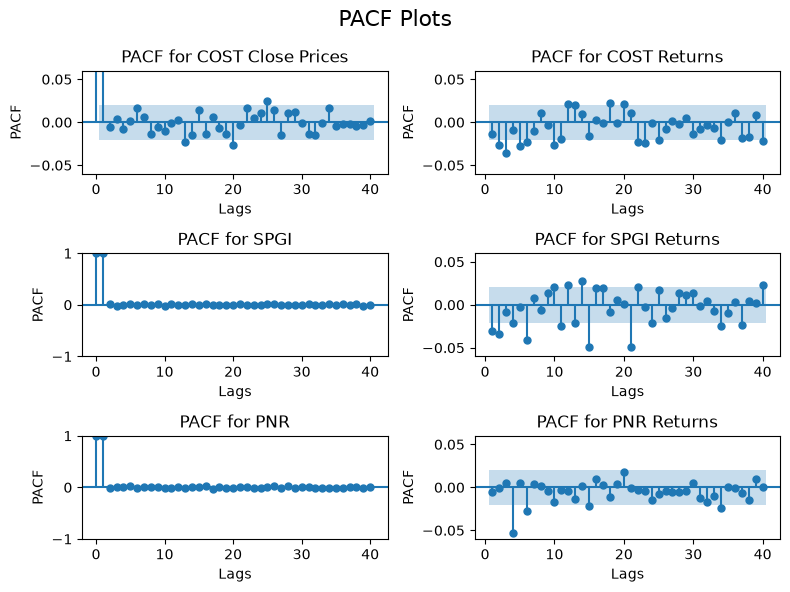

In [21]:
fig, ax = plt.subplots(3,2, figsize=(8,6))

plot_pacf(stocks.loc[:,('Close','COST')], ax=ax[0,0])
ax[0,0].set_xlabel('Lags')
ax[0,0].set_ylabel('PACF')
ax[0,0].set_ylim(-0.06,0.06)
ax[0,0].set_title('PACF for COST Close Prices')

plot_pacf(stocks.loc[:,('Close','SPGI')], ax=ax[1,0])
ax[1,0].set_xlabel('Lags')
ax[1,0].set_ylabel('PACF')
ax[1,0].set_title('PACF for SPGI')

plot_pacf(stocks.loc[:,('Close','PNR')], ax=ax[2,0])
ax[2,0].set_xlabel('Lags')
ax[2,0].set_ylabel('PACF')
ax[2,0].set_title('PACF for PNR')

plot_pacf(returns['COST'].dropna(), lags=40, zero=False, ax=ax[0,1])
ax[0,1].set_xlabel('Lags')
ax[0,1].set_ylabel('PACF')
ax[0,1].set_title('PACF for COST Returns')
ax[0,1].set_ylim(-0.06,0.06)

plot_pacf(returns['SPGI'].dropna(), lags=40, zero=False, ax=ax[1,1])
ax[1,1].set_xlabel('Lags')
ax[1,1].set_ylabel('PACF')
ax[1,1].set_title('PACF for SPGI Returns')
ax[1,1].set_ylim(-0.06,0.06)

plot_pacf(returns['PNR'].dropna(), lags=40, zero=False, ax=ax[2,1])
ax[2,1].set_xlabel('Lags')
ax[2,1].set_ylabel('PACF')
ax[2,1].set_title('PACF for PNR Returns')
ax[2,1].set_ylim(-0.06,0.06)

fig.suptitle('PACF Plots', fontsize=16)
plt.tight_layout()


## Model Fitting

We split the data into a training set (80%) and a validation set (20%) before fitting any models. Since this is time series data, we use a chronological split rather than a random one. Splitting randomly would allow the model to train on data from after the point it is being asked to predict, which is a form of look-ahead bias. We will then use the reamining 2026 data as the final test set.

In [18]:
# Chronological 80/20 train/validation split

split_idx = int(len(returns) * 0.8)

train = returns.iloc[:split_idx]
validation = returns.iloc[split_idx:]

print(f'Train:      {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)')
print(f'Validation: {validation.index.min().date()} to {validation.index.max().date()} ({len(validation)} rows)')

Train:      1990-01-02 to 2018-10-11 (7253 rows)
Validation: 2018-10-12 to 2025-12-31 (1814 rows)


### ARIMA

We begin with an ARIMA model, fitted separately to each stock's returns on the training set. We previously determined that returns are sationary by implementing a ADF test, which suggests no differencing is required for the model. We thus choose $d=0$. The ACF and PACF plots for returns provides us with a sensible range to perform a grid search over to find the best AIMRA model. For COST returns specifically, we will scan over integer values in the range $p, q \in [0,10]$ and measure model validity using AIC.

In [30]:
# Perform a grid search for p, q in [0,10] and d=0
d = 0

# Collect all 3 models in a dictionary
best_arima_models = {}

# Suppress unnecessary warnings about lack of frequency information for dates
warnings.filterwarnings('ignore', category=ValueWarning)

# Implement grid search
for ticker in ['COST']:  #  remove comment when you want to fit all 3 models ['COST', 'SPGI', 'PNR']:   
    best_p = 0
    best_q = 0
    best_aic = np.inf
    for p in range(11):
        for q in range(11):
            try:
                model = ARIMA(train[ticker], order=(p, d, q)).fit()
                if model.aic < best_aic:
                    best_p = p
                    best_q = q
                    best_aic = model.aic
                    best_model = model
            except Exception as e:
                print(f'Model fitting failed for (p,q)={(p,q)}')
                print(f'Error message: {e}')
    best_arima_models[ticker] = best_model

print(f'Best AIC: {best_aic} \n Best (p,d,q) = {(best_p, d, best_q)}')

d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\conda_envs\sto

Best AIC: -36086.58265142247 
 Best (p,d,q) = (4, 0, 6)


In [37]:
# Make predictions for the validation dataset.
# Refit the model after every month (20 trading days)

model = best_arima_models['COST']
model_order = model.model.order
predictions = []
no_of_iterations = int(np.ceil(len(validation)/20))

for t in tqdm(range(no_of_iterations)):
    steps = min(20, len(validation) - t*20)
    predictions.extend(model.forecast(steps=steps).tolist())
    expanded_train_set = pd.concat([train, validation.iloc[0:20*t]])
    model = ARIMA(expanded_train_set['COST'], order=model_order).fit()

  0%|          | 0/91 [00:00<?, ?it/s]

d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
  1%|          | 1/91 [00:13<20:53, 13.93s/it]d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
  2%|▏         | 2/91 [00:32<24:20, 16.41s/it]d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\conda_envs\stock-price-prediction\Lib\site-packages\statsmodels\b

We generate a quick visual check of the COST model against the validation set. The model produces a single static forecast for the entire validation horizon from the end of the training data - it does not see any of the true validation values as it goes. This means errors will compound over the horizon, and we'd expect the forecast to flatten out toward a trend rather than track real price movements. This is only a first look; proper walk-forward validation (mentioned in the intro) will give a fairer assessment later.

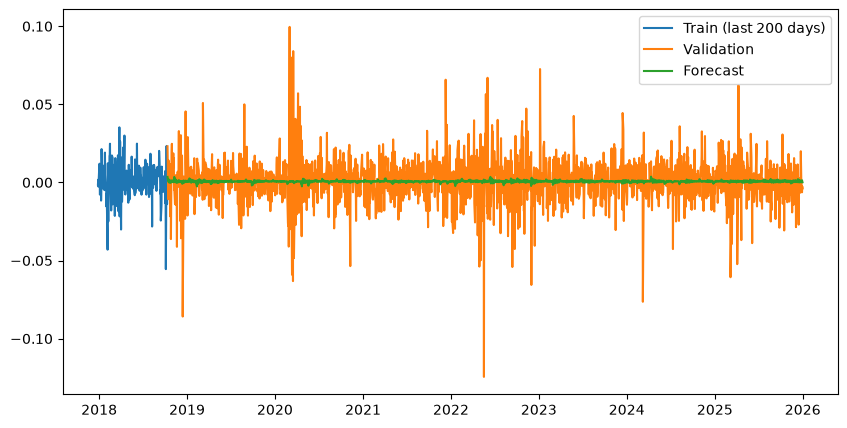

In [41]:
predictions = pd.Series(predictions, index=validation.index)

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(train.loc[:, ('COST')].iloc[-200:], label='Train (last 200 days)')
ax.plot(validation.loc[:, ('COST')], label='Validation')
ax.plot(predictions, label='Forecast')
ax.legend()

In [95]:
# Measure directional accuracy

acc = np.mean((predictions>=0) == (validation['COST']>=0))
print(f'Directional accuracy of ARIMA model on COST returns: {acc : .2%}')

Directional accuracy of ARIMA model on COST returns:  53.31%


In [ ]:
# Implement Pesaran-Timermann test

n = len(validation)
P_hat = sum((predictions>0) == (validation['COST']>0)) / n
P_hat_y = sum(validation['COST']>0) / n
P_hat_x = sum(predictions>0) / n
P_hat_star = P_hat_x * P_hat_y + (1-P_hat_x)*(1-P_hat_y)
var_p_hat = P_hat_star * (1 - P_hat_star) / n
var_p_hat_star = ((2*P_hat_y-1)**2)*P_hat_x*(1-P_hat_x)/n + ((2*P_hat_x - 1)**2)*P_hat_y*(1-P_hat_y)/n + 4*P_hat_x*P_hat_y*(1-P_hat_x)*(1-P_hat_y)/(n**2)
test_statistic = (P_hat - P_hat_star)/np.sqrt(var_p_hat - var_p_hat_star)
p_value = 2*stats.norm.sf(np.abs(test_statistic))
print(f'p-value for Pesaran-Timermann test for directional accuracy: {p_value}')

p-value for Pesaran-Timermann test for directional accuracy: 0.45474205255639255


In [98]:
# Save models that took a long time to run for convenience

import pickle

# Save predictions
predictions.to_csv('cost_predictions.csv')

# Save models
with open('best_arima_models.pkl', 'wb') as f:
    pickle.dump(best_arima_models, f)

# Load it back tomorrow
#with open('cost_arima.pkl', 'rb') as f:
#    best_arima_models = pickle.load(f)

with open('grid_search_results.pkl', 'wb') as f:
    pickle.dump(model_order, f)

## Model Evaluation

## Conclusion